In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

In [4]:
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
x

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [5]:
y = np.array([40, 50, 50, 60, 70])
y

array([40, 50, 50, 60, 70])

In [6]:
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


In [7]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  33.0
Slope :  7.0


In [43]:
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- income
Feature names seen at fit time, yet now missing:
- Assignment_Score
- Attendance
- Study_Hours


In [11]:
print("predicted mark : ", predicted_mark[0])

predicted mark :  75.0


In [12]:
y_pred = model.predict(x)
y_pred

array([40., 47., 54., 61., 68.])

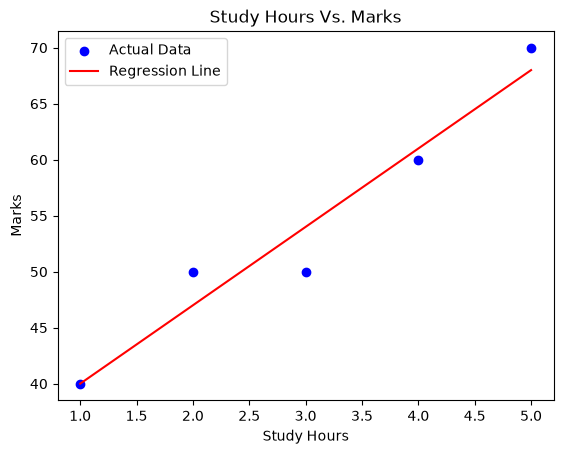

In [20]:
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, y_pred, color = "red", label = "Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks")
#plt.grid(True)
plt.legend()
plt.show()


In [21]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [26]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

In [27]:
print("Mean Absolute Error : ", mae)
print("Mean Squared Error : ", mse)
print("Root Mean Squared Error : ", rmse)
print("R-squared : ", r2)

Mean Absolute Error :  2.0
Mean Squared Error :  6.0
Root Mean Squared Error :  2.449489742783178
R-squared :  0.9423076923076923


Train_test_split

In [29]:
import pandas as pd 
from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#import numpy as np


In [30]:
data = {
    "Study_Hours" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks"       : [32, 38, 43, 50, 54, 61, 68, 73, 81, 88]
}

In [31]:
df = pd.DataFrame(data)
df

,Study_Hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [37]:
x = df[["Study_Hours"]]
y = df["Marks"]

In [38]:
x

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [39]:
y

0    32
1    38
2    43
3    50
4    54
5    61
6    68
7    73
8    81
9    88
Name: Marks, dtype: int64

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [61]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [62]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  24.724137931034484
Slope :  6.163793103448276
Actual values :  [81 38]
Predicted values :  [80.19827586 37.05172414]


In [64]:
print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.875
MSE       :  0.7709943519619504
RMSE      :  0.8780628405541089
R-squared :  0.9983320836085193


Multiple linear regression in Python

In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [13]:
data = {
    "Study_Hours" : [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance"  : [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignment_Score" : [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_Marks" : [42, 48, 54, 61, 67, 73, 81, 89]
}

df = pd.DataFrame(data)

In [14]:
x = df[["Study_Hours","Attendance","Assignment_Score"]]
y = df["Final_Marks"]

In [23]:
model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x_test)

print("Intercept : ", model.intercept_)

Intercept :  -28.31652806652808


In [24]:
coefficient_table = pd.DataFrame({
    "Feature" : x.columns,
    "Coefficient" : model.coef_
})

In [25]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.131410
1        Attendance     0.657051
2  Assignment_Score     0.608108


In [26]:
new_student = pd.DataFrame({
    "Study_Hours" : [6],
    "Attendance" : [82],
    "Assignment_Score" : [72]
})

In [27]:
prediction = model.predict(new_student)

print("Predicted final mark : ", prediction[0])

Predicted final mark :  70.13392238392238


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [33]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  -28.31652806652808
Slope :  0.13141025641025642
Actual values :  [48 73]
Predicted values :  [48.23198198 73.4527027 ]


In [34]:
print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.3423423423423415
MSE       :  0.12937768849931108
RMSE      :  0.3596911015014287
R-squared :  0.9991719827936044


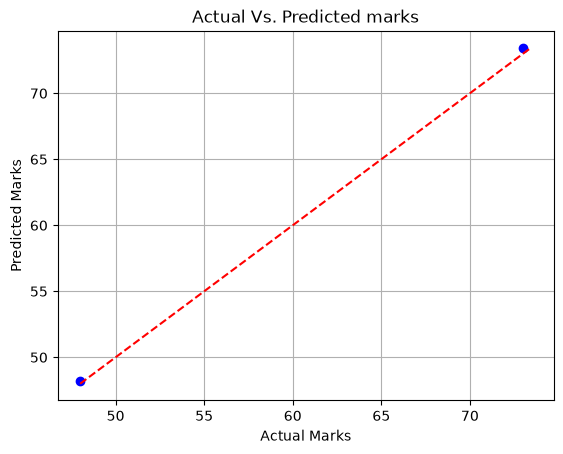

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()

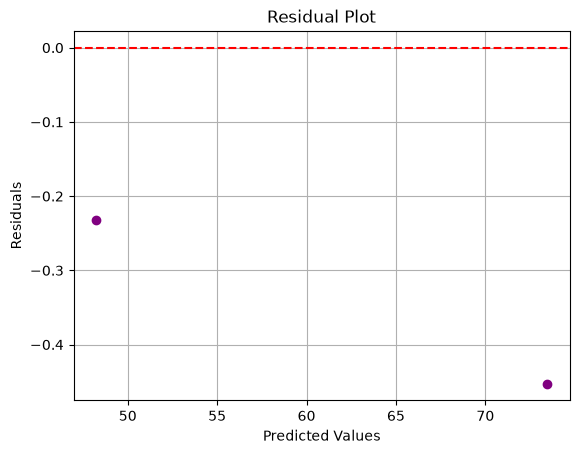

In [35]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

Using dataset

Intro to how get_dummies or encoding can be done

In [19]:
import pandas as pd

data = {
    "Size" : [800, 1000, 1200, 1500, 1800],
    "Location" : ["Rural", "Urban", "Rural", "Urban", "Urban"],
    "Price" : [30, 50, 42, 72, 85]
}

df = pd.DataFrame(data)
df

,Size,Location,Price
0,800,Rural,30
1,1000,Urban,50
2,1200,Rural,42
3,1500,Urban,72
4,1800,Urban,85


In [20]:
#Try with label encoding
df_encoded = pd.get_dummies(
    df,
    columns = ["Location"],
    drop_first  = True,
    dtype = int
)

print(df_encoded)

   Size  Price  Location_Urban
0   800     30               0
1  1000     50               1
2  1200     42               0
3  1500     72               1
4  1800     85               1


#graph whcih train data = green, test data = red